ЭКСПЕРИМЕНТ 3.1: Траектории градиентного спуска


/tmp/ipython-input-4214303160.py:379: UserWarning: The following kwargs were not used by contour: 'linewidth'
  CS = plt.contour(X, Y, Z, levels=levels, colors='k', linewidth=2.0)
/tmp/ipython-input-4214303160.py:271: RuntimeWarning: invalid value encountered in add
  x_k += alpha_k * d_k


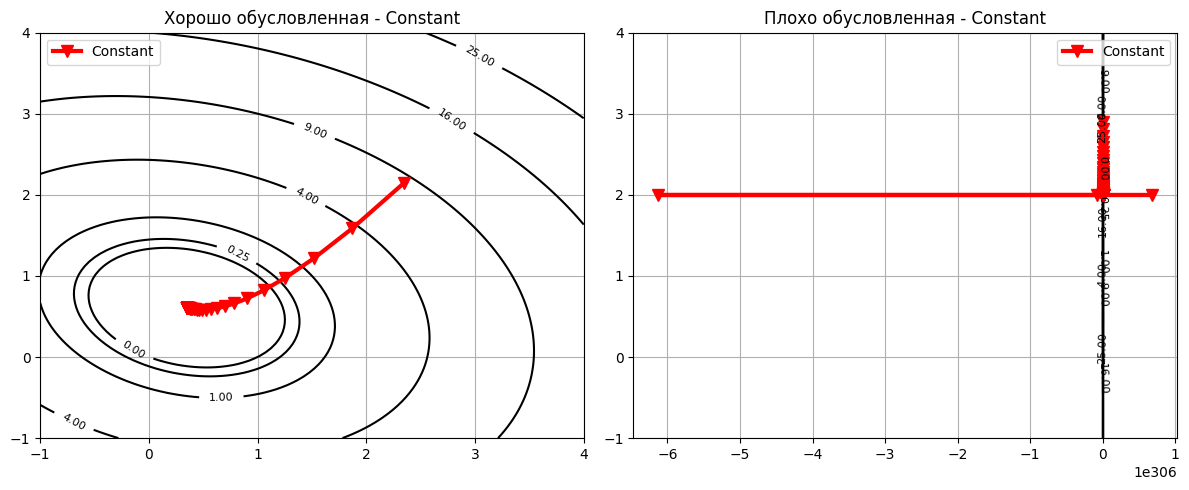

Стратегия Constant:
  Хорошо обусловленная: success, итераций: 64
  Плохо обусловленная: iterations_exceeded, итераций: 1000


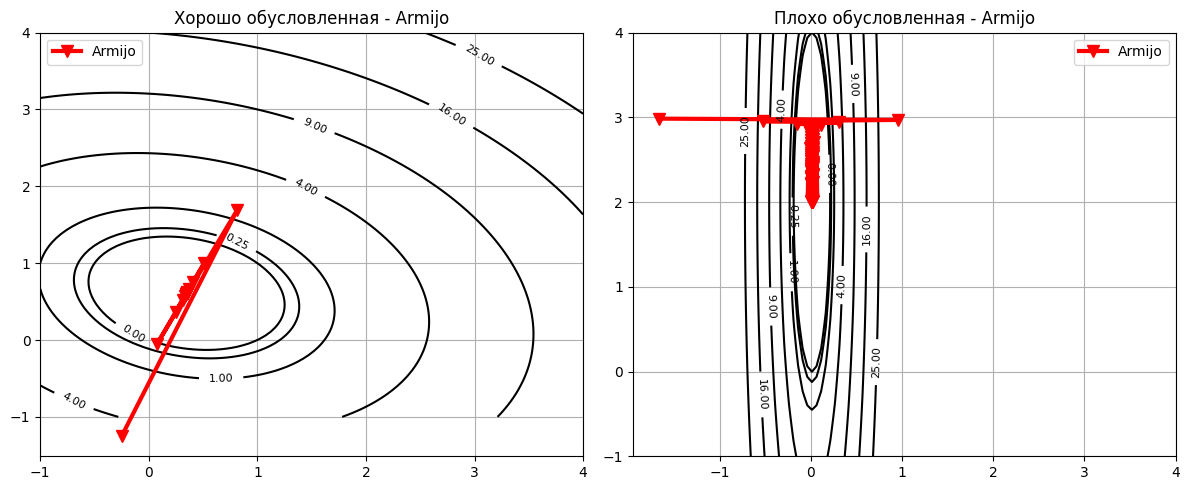

Стратегия Armijo:
  Хорошо обусловленная: success, итераций: 28
  Плохо обусловленная: success, итераций: 376


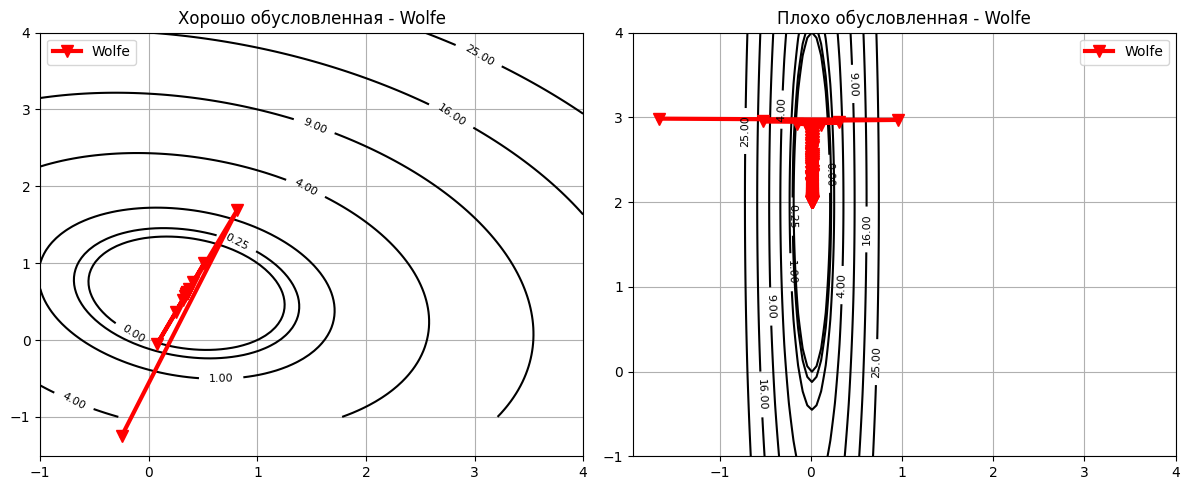

Стратегия Wolfe:
  Хорошо обусловленная: success, итераций: 28
  Плохо обусловленная: success, итераций: 385

ЭКСПЕРИМЕНТ 3.2: Зависимость от числа обусловленности
n=10, κ=1.0, средние итерации: 1.0
n=10, κ=2.8, средние итерации: 16.7
n=10, κ=7.7, средние итерации: 47.7
n=10, κ=21.5, средние итерации: 93.0
n=10, κ=59.9, средние итерации: 283.3
n=10, κ=166.8, средние итерации: 544.7
n=10, κ=464.2, средние итерации: 1000.0
n=10, κ=1291.5, средние итерации: 1000.0
n=10, κ=3593.8, средние итерации: 1000.0
n=10, κ=10000.0, средние итерации: 1000.0
n=100, κ=1.0, средние итерации: 1.0
n=100, κ=2.8, средние итерации: 16.0
n=100, κ=7.7, средние итерации: 45.3
n=100, κ=21.5, средние итерации: 85.3
n=100, κ=59.9, средние итерации: 244.0
n=100, κ=166.8, средние итерации: 463.3
n=100, κ=464.2, средние итерации: 1000.0
n=100, κ=1291.5, средние итерации: 1000.0
n=100, κ=3593.8, средние итерации: 1000.0
n=100, κ=10000.0, средние итерации: 1000.0


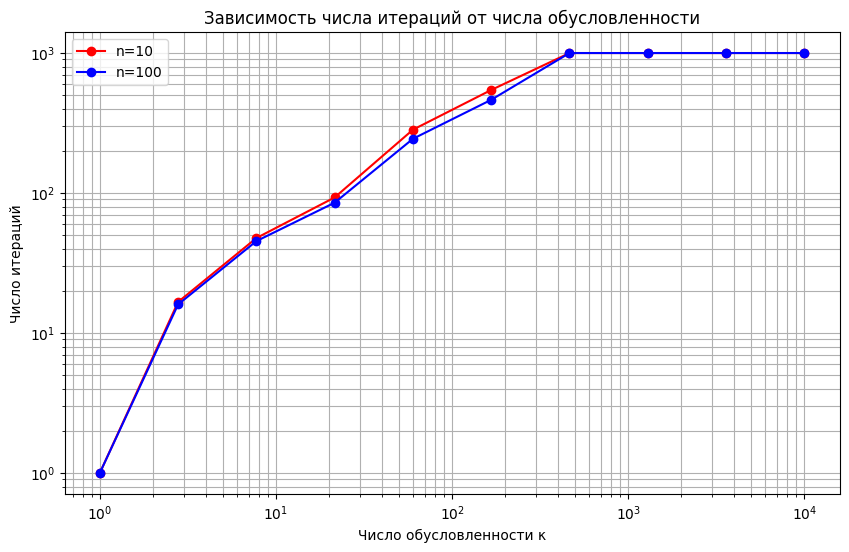


Анализ результатов эксперимента 3.2:
Чем больше число обусловленности κ, тем больше итераций требуется для сходимости.
Это связано с тем, что в плохо обусловленных задачах градиентный спуск 'осциллирует'
вдоль направления с маленькой кривизной, делая очень маленькие шаги.

ЭКСПЕРИМЕНТ 3.3: Сравнение методов на реальных данных
Скачиваем w8a...
Датасет: w8a
Размеры: m=49749, n=300
Запуск градиентного спуска...
Запуск метода Ньютона...


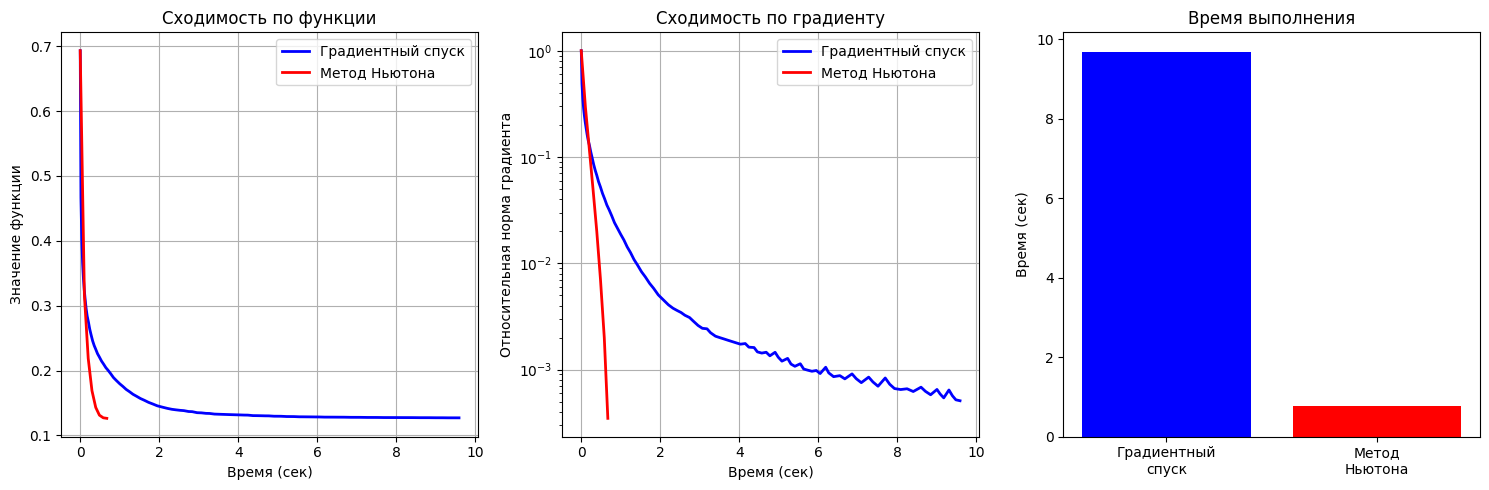


РЕЗУЛЬТАТЫ:
Градиентный спуск: iterations_exceeded, время: 9.70 сек, итераций: 100
Метод Ньютона: success, время: 0.78 сек, итераций: 8

ОЦЕНКА СЛОЖНОСТИ:
Градиентный спуск: O(mn) за итерацию, O(n) памяти
Метод Ньютона: O(mn² + n³) за итерацию, O(n²) памяти

ПРОВЕРКА ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ
Значение функции: 0.9776597550179785
Норма градиента: 0.28973963198250025
Размерность гессиана: (5, 5)

Все эксперименты завершены!


In [15]:

!pip install scikit-learn

import numpy as np
import scipy
import scipy.sparse
from scipy.special import expit
from scipy.linalg import cho_factor, cho_solve
from sklearn.datasets import load_svmlight_file
import matplotlib.pyplot as plt
from collections import defaultdict
import time
import urllib.request
import os

class BaseSmoothOracle(object):
    def func(self, x):
        raise NotImplementedError('Func oracle is not implemented.')

    def grad(self, x):
        raise NotImplementedError('Grad oracle is not implemented.')

    def hess(self, x):
        raise NotImplementedError('Hessian oracle is not implemented.')

    def func_directional(self, x, d, alpha):
        return np.squeeze(self.func(x + alpha * d))

    def grad_directional(self, x, d, alpha):
        return np.squeeze(self.grad(x + alpha * d).dot(d))

class QuadraticOracle(BaseSmoothOracle):
    def __init__(self, A, b):
        if not scipy.sparse.isspmatrix_dia(A) and not np.allclose(A, A.T):
            raise ValueError('A should be a symmetric matrix.')
        self.A = A
        self.b = b

    def func(self, x):
        return 0.5 * np.dot(self.A.dot(x), x) - self.b.dot(x)

    def grad(self, x):
        return self.A.dot(x) - self.b

    def hess(self, x):
        return self.A

class LogRegL2Oracle(BaseSmoothOracle):
    def __init__(self, matvec_Ax, matvec_ATx, matmat_ATsA, b, regcoef):
        self.matvec_Ax = matvec_Ax
        self.matvec_ATx = matvec_ATx
        self.matmat_ATsA = matmat_ATsA
        self.b = b
        self.regcoef = regcoef
        self.m = len(b)

    def func(self, x):
        Ax = self.matvec_Ax(x)
        z = self.b * Ax
        log_loss = np.logaddexp(0, -z).mean()
        reg = 0.5 * self.regcoef * np.dot(x, x)
        return log_loss + reg

    def grad(self, x):
        Ax = self.matvec_Ax(x)
        z = self.b * Ax
        sigma_vec = expit(-z)
        grad_loss = self.matvec_ATx(-self.b * sigma_vec) / self.m
        grad_reg = self.regcoef * x
        return grad_loss + grad_reg

    def hess(self, x):
        Ax = self.matvec_Ax(x)
        z = self.b * Ax
        sigma_vec = expit(z)
        s = sigma_vec * (1 - sigma_vec)
        hess_loss = self.matmat_ATsA(s) / self.m
        if scipy.sparse.issparse(hess_loss):
            n = hess_loss.shape[0]
            hess_reg = self.regcoef * scipy.sparse.identity(n)
        else:
            n = hess_loss.shape[0]
            hess_reg = self.regcoef * np.eye(n)
        return hess_loss + hess_reg

def create_log_reg_oracle(A, b, regcoef, oracle_type='usual'):
    if scipy.sparse.issparse(A):
        def matvec_Ax(x):
            return A.dot(x)

        def matvec_ATx(x):
            return A.T.dot(x)

        def matmat_ATsA(s):
            return A.T.dot(scipy.sparse.diags(s).dot(A))
    else:
        def matvec_Ax(x):
            return A.dot(x)

        def matvec_ATx(x):
            return A.T.dot(x)

        def matmat_ATsA(s):
            return A.T.dot(s[:, np.newaxis] * A)

    if oracle_type == 'usual':
        return LogRegL2Oracle(matvec_Ax, matvec_ATx, matmat_ATsA, b, regcoef)
    else:
        raise ValueError('Unknown oracle_type=%s' % oracle_type)

def grad_finite_diff(func, x, eps=1e-8):
    n = len(x)
    grad = np.zeros(n)
    f_x = func(x)

    for i in range(n):
        e_i = np.zeros(n)
        e_i[i] = 1
        f_plus = func(x + eps * e_i)
        grad[i] = (f_plus - f_x) / eps

    return grad

def hess_finite_diff(func, x, eps=1e-5):
    n = len(x)
    hess = np.zeros((n, n))
    f_x = func(x)

    for i in range(n):
        e_i = np.zeros(n)
        e_i[i] = 1
        f_plus_i = func(x + eps * e_i)

        for j in range(i, n):
            e_j = np.zeros(n)
            e_j[j] = 1
            f_plus_j = func(x + eps * e_j)
            f_plus_ij = func(x + eps * e_i + eps * e_j)

            hess_ij = (f_plus_ij - f_plus_i - f_plus_j + f_x) / (eps * eps)
            hess[i, j] = hess_ij
            if i != j:
                hess[j, i] = hess_ij

    return hess

#optimization.py

class LineSearchTool(object):
    def __init__(self, method='Wolfe', **kwargs):
        self._method = method
        if self._method == 'Wolfe':
            self.c1 = kwargs.get('c1', 1e-4)
            self.c2 = kwargs.get('c2', 0.9)
            self.alpha_0 = kwargs.get('alpha_0', 1.0)
        elif self._method == 'Armijo':
            self.c1 = kwargs.get('c1', 1e-4)
            self.alpha_0 = kwargs.get('alpha_0', 1.0)
        elif self._method == 'Constant':
            self.c = kwargs.get('c', 1.0)
        else:
            raise ValueError('Unknown method {}'.format(method))

    @classmethod
    def from_dict(cls, options):
        if type(options) != dict:
            raise TypeError('LineSearchTool initializer must be of type dict')
        return cls(**options)

    def line_search(self, oracle, x_k, d_k, previous_alpha=None):
        if self._method == 'Constant':
            return self.c

        elif self._method == 'Armijo':
            if previous_alpha is not None:
                alpha = previous_alpha
            else:
                alpha = self.alpha_0

            phi_0 = float(oracle.func_directional(x_k, d_k, 0))
            phi_prime_0 = float(oracle.grad_directional(x_k, d_k, 0))

            while oracle.func_directional(x_k, d_k, alpha) > phi_0 + self.c1 * alpha * phi_prime_0:
                alpha /= 2
                if alpha < 1e-16:
                    return None
            return alpha

        elif self._method == 'Wolfe':
            def phi(alpha):
                return float(oracle.func_directional(x_k, d_k, alpha))

            def phi_prime(alpha):
                return float(oracle.grad_directional(x_k, d_k, alpha))

            phi_0 = phi(0)
            phi_prime_0 = phi_prime(0)

            return self.wolfe_line_search(phi, phi_prime, phi_0, phi_prime_0)

    def wolfe_line_search(self, phi, phi_prime, phi_0, phi_prime_0):
        alpha = self.alpha_0
        max_iter = 50

        for i in range(max_iter):
            phi_alpha = phi(alpha)
            phi_prime_alpha = phi_prime(alpha)

            armijo_condition = phi_alpha <= phi_0 + self.c1 * alpha * phi_prime_0
            curvature_condition = abs(phi_prime_alpha) <= self.c2 * abs(phi_prime_0)

            if armijo_condition and curvature_condition:
                return alpha

            if not armijo_condition:
                alpha /= 2
            else:
                alpha *= 1.5

            if alpha < 1e-16 or alpha > 1e16:
                break

        alpha = self.alpha_0
        while phi(alpha) > phi_0 + self.c1 * alpha * phi_prime_0:
            alpha /= 2
            if alpha < 1e-16:
                return None
        return alpha

def get_line_search_tool(line_search_options=None):
    if line_search_options:
        if type(line_search_options) is LineSearchTool:
            return line_search_options
        else:
            return LineSearchTool.from_dict(line_search_options)
    else:
        return LineSearchTool()

def gradient_descent(oracle, x_0, tolerance=1e-5, max_iter=10000,
                     line_search_options=None, trace=False, display=False):
    start_time = time.time()
    history = defaultdict(list) if trace else None
    line_search_tool = get_line_search_tool(line_search_options)
    x_k = np.copy(x_0)

    grad_0 = oracle.grad(x_0)
    grad_norm_0 = np.linalg.norm(grad_0)

    previous_alpha = None

    for k in range(max_iter):
        current_time = time.time() - start_time

        f_k = oracle.func(x_k)
        grad_k = oracle.grad(x_k)
        grad_norm_k = np.linalg.norm(grad_k)

        if grad_norm_k <= tolerance * grad_norm_0:
            message = 'success'
            break

        d_k = -grad_k

        alpha_k = line_search_tool.line_search(oracle, x_k, d_k, previous_alpha)

        if alpha_k is None or np.isnan(alpha_k) or np.isinf(alpha_k):
            message = 'computational_error'
            break

        x_k += alpha_k * d_k

        if line_search_tool._method != 'Wolfe':
            previous_alpha = 2 * alpha_k

        if trace:
            history['time'].append(current_time)
            history['func'].append(float(f_k))
            history['grad_norm'].append(float(grad_norm_k))
            if x_k.size <= 2:
                history['x'].append(x_k.copy())

        if display and k % 10 == 0:
            print(f"Iteration {k}: f(x) = {f_k:.6f}, ||grad|| = {grad_norm_k:.6f}, alpha = {alpha_k:.6f}")

    else:
        message = 'iterations_exceeded'

    if display:
        print(f"Final: f(x) = {oracle.func(x_k):.6f}, ||grad|| = {np.linalg.norm(oracle.grad(x_k)):.6f}")

    return x_k, message, history

def newton(oracle, x_0, tolerance=1e-5, max_iter=100,
           line_search_options=None, trace=False, display=False):
    start_time = time.time()
    history = defaultdict(list) if trace else None
    line_search_tool = get_line_search_tool(line_search_options)
    x_k = np.copy(x_0)

    grad_0 = oracle.grad(x_0)
    grad_norm_0 = np.linalg.norm(grad_0)

    for k in range(max_iter):
        current_time = time.time() - start_time

        f_k = oracle.func(x_k)
        grad_k = oracle.grad(x_k)
        grad_norm_k = np.linalg.norm(grad_k)

        if grad_norm_k <= tolerance * grad_norm_0:
            message = 'success'
            break

        try:
            hess_k = oracle.hess(x_k)

            if scipy.sparse.issparse(hess_k):
                try:
                    d_k = -scipy.sparse.linalg.spsolve(hess_k, grad_k)
                except:
                    hess_k_dense = hess_k.toarray()
                    c, lower = cho_factor(hess_k_dense)
                    d_k = -cho_solve((c, lower), grad_k)
            else:
                c, lower = cho_factor(hess_k)
                d_k = -cho_solve((c, lower), grad_k)

        except (np.linalg.LinAlgError, ValueError) as e:
            if display:
                print(f"LinAlgError at iteration {k}: {e}")
            message = 'newton_direction_error'
            break

        alpha_k = line_search_tool.line_search(oracle, x_k, d_k, previous_alpha=1.0)

        if alpha_k is None or np.isnan(alpha_k) or np.isinf(alpha_k):
            message = 'computational_error'
            break

        x_k += alpha_k * d_k

        if trace:
            history['time'].append(current_time)
            history['func'].append(float(f_k))
            history['grad_norm'].append(float(grad_norm_k))
            if x_k.size <= 2:
                history['x'].append(x_k.copy())

        if display:
            print(f"Iteration {k}: f(x) = {f_k:.6f}, ||grad|| = {grad_norm_k:.6f}, alpha = {alpha_k:.6f}")

    else:
        message = 'iterations_exceeded'

    if display:
        print(f"Final: f(x) = {oracle.func(x_k):.6f}, ||grad|| = {np.linalg.norm(oracle.grad(x_k)):.6f}")

    return x_k, message, history

#ФУНКЦИИ ДЛЯ ГРАФИКОВ

def plot_levels(func, xrange=None, yrange=None, levels=None):
    if xrange is None:
        xrange = [-6, 6]
    if yrange is None:
        yrange = [-5, 5]
    if levels is None:
        levels = [0, 0.25, 1, 4, 9, 16, 25]

    x = np.linspace(xrange[0], xrange[1], 100)
    y = np.linspace(yrange[0], yrange[1], 100)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros(X.shape)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            Z[i, j] = func(np.array([X[i, j], Y[i, j]]))

    CS = plt.contour(X, Y, Z, levels=levels, colors='k', linewidth=2.0)
    plt.clabel(CS, inline=1, fontsize=8)
    plt.grid()

def plot_trajectory(history, fit_axis=False, label=None):
    x_values, y_values = zip(*history)
    plt.plot(x_values, y_values, '-v', linewidth=3.0, ms=8.0,
             alpha=1.0, c='r', label=label)

    if fit_axis:
        xmax, ymax = np.max(x_values), np.max(y_values)
        COEF = 1.5
        xrange = [-xmax * COEF, xmax * COEF]
        yrange = [-ymax * COEF, ymax * COEF]
        plt.xlim(xrange)
        plt.ylim(yrange)

# ЭКСПЕРИМЕНТ 3.1

print("ЭКСПЕРИМЕНТ 3.1: Траектории градиентного спуска")

# Функция 1: Хорошо обусловленная
A1 = np.array([[2.0, 0.5], [0.5, 3.0]])
b1 = np.array([1.0, 2.0])
oracle1 = QuadraticOracle(A1, b1)

# Функция 2: Плохо обусловленная
A2 = np.array([[100.0, 0.0], [0.0, 1.0]])
b2 = np.array([1.0, 2.0])
oracle2 = QuadraticOracle(A2, b2)

x0 = np.array([3.0, 3.0])

strategies = [
    {'method': 'Constant', 'c': 0.1},
    {'method': 'Armijo', 'alpha_0': 1.0},
    {'method': 'Wolfe'}
]

strategy_names = ['Constant', 'Armijo', 'Wolfe']

for i, (strategy, name) in enumerate(zip(strategies, strategy_names)):
    plt.figure(figsize=(12, 5))

    # Функция 1
    plt.subplot(1, 2, 1)
    plot_levels(oracle1.func, xrange=[-1, 4], yrange=[-1, 4])
    x_star1, msg1, history1 = gradient_descent(
        oracle1, x0, tolerance=1e-6, max_iter=1000,
        line_search_options=strategy, trace=True
    )
    if history1 and 'x' in history1:
        plot_trajectory(history1['x'], label=name)
    plt.title(f'Хорошо обусловленная - {name}')
    plt.legend()

    # Функция 2
    plt.subplot(1, 2, 2)
    plot_levels(oracle2.func, xrange=[-1, 4], yrange=[-1, 4])
    x_star2, msg2, history2 = gradient_descent(
        oracle2, x0, tolerance=1e-6, max_iter=1000,
        line_search_options=strategy, trace=True
    )
    if history2 and 'x' in history2:
        plot_trajectory(history2['x'], label=name)
    plt.title(f'Плохо обусловленная - {name}')
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"Стратегия {name}:")
    print(f"  Хорошо обусловленная: {msg1}, итераций: {len(history1['func']) if history1 else 'N/A'}")
    print(f"  Плохо обусловленная: {msg2}, итераций: {len(history2['func']) if history2 else 'N/A'}")

#ЭКСПЕРИМЕНТ 3.2

print("\nЭКСПЕРИМЕНТ 3.2: Зависимость от числа обусловленности")

def generate_quadratic_problem(n, kappa):
    a = np.linspace(1, kappa, n)
    A = np.diag(a)
    b = np.random.randn(n)
    return A, b

# Параметры
n_values = [10, 100]
kappa_values = np.logspace(0, 4, 10)
num_trials = 3

plt.figure(figsize=(10, 6))
colors = ['red', 'blue']

for n_idx, n in enumerate(n_values):
    iterations_per_kappa = []

    for kappa in kappa_values:
        kappa_iterations = []

        for trial in range(num_trials):
            A, b = generate_quadratic_problem(n, kappa)
            oracle = QuadraticOracle(A, b)
            x0 = np.ones(n) * 5.0

            _, msg, history = gradient_descent(
                oracle, x0, tolerance=1e-6, max_iter=1000,
                line_search_options={'method': 'Wolfe'}, trace=True
            )

            if history:
                kappa_iterations.append(len(history['func']))
            else:
                kappa_iterations.append(1000)

        iterations_per_kappa.append(np.mean(kappa_iterations))
        print(f"n={n}, κ={kappa:.1f}, средние итерации: {np.mean(kappa_iterations):.1f}")

    plt.loglog(kappa_values, iterations_per_kappa, 'o-', color=colors[n_idx], label=f'n={n}')

plt.xlabel('Число обусловленности κ')
plt.ylabel('Число итераций')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.title('Зависимость числа итераций от числа обусловленности')
plt.show()

print("\nАнализ результатов эксперимента 3.2:")
print("Чем больше число обусловленности κ, тем больше итераций требуется для сходимости.")
print("Это связано с тем, что в плохо обусловленных задачах градиентный спуск 'осциллирует'")
print("вдоль направления с маленькой кривизной, делая очень маленькие шаги.")

# ЭКСПЕРИМЕНТ 3.3

print("\nЭКСПЕРИМЕНТ 3.3: Сравнение методов на реальных данных")

# Скачиваем датасеты
if not os.path.exists('data'):
    os.makedirs('data')

datasets_info = {
    'w8a': 'https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/w8a',
    'gisette': 'https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/gisette_scale.bz2',
    'real-sim': 'https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/real-sim.bz2'
}


dataset_name = 'w8a'
url = datasets_info[dataset_name]
file_path = f'data/{dataset_name}'

print(f"Скачиваем {dataset_name}...")
urllib.request.urlretrieve(url, file_path)

A, b = load_svmlight_file(file_path)
b = b.astype(np.int32)
b = np.where(b == 1, 1, -1)

m, n = A.shape
regcoef = 1.0 / m

print(f"Датасет: {dataset_name}")
print(f"Размеры: m={m}, n={n}")

oracle = create_log_reg_oracle(A, b, regcoef)

x0 = np.zeros(n)

# Запуск
print("Запуск градиентного спуска...")
start_time = time.time()
x_gd, msg_gd, history_gd = gradient_descent(
    oracle, x0, tolerance=1e-4, max_iter=100,
    line_search_options={'method': 'Wolfe'}, trace=True
)
time_gd = time.time() - start_time

print("Запуск метода Ньютона...")
start_time = time.time()
x_nt, msg_nt, history_nt = newton(
    oracle, x0, tolerance=1e-4, max_iter=50,
    line_search_options={'method': 'Constant', 'c': 1.0}, trace=True
)
time_nt = time.time() - start_time

plt.figure(figsize=(15, 5))

# График 1: Значение функции от времени
plt.subplot(1, 3, 1)
if history_gd:
    plt.plot(history_gd['time'], history_gd['func'], 'b-', label='Градиентный спуск', linewidth=2)
if history_nt:
    plt.plot(history_nt['time'], history_nt['func'], 'r-', label='Метод Ньютона', linewidth=2)
plt.xlabel('Время (сек)')
plt.ylabel('Значение функции')
plt.legend()
plt.grid(True)
plt.title('Сходимость по функции')

# График 2: Норма градиента от времени
plt.subplot(1, 3, 2)
if history_gd:
    grad_norm_rel_gd = [gn / history_gd['grad_norm'][0] for gn in history_gd['grad_norm']]
    plt.semilogy(history_gd['time'], grad_norm_rel_gd, 'b-', label='Градиентный спуск', linewidth=2)
if history_nt:
    grad_norm_rel_nt = [gn / history_nt['grad_norm'][0] for gn in history_nt['grad_norm']]
    plt.semilogy(history_nt['time'], grad_norm_rel_nt, 'r-', label='Метод Ньютона', linewidth=2)
plt.xlabel('Время (сек)')
plt.ylabel('Относительная норма градиента')
plt.legend()
plt.grid(True)
plt.title('Сходимость по градиенту')

# График 3: Сравнение времени
plt.subplot(1, 3, 3)
methods = ['Градиентный\nспуск', 'Метод\nНьютона']
times = [time_gd, time_nt]
plt.bar(methods, times, color=['blue', 'red'])
plt.ylabel('Время (сек)')
plt.title('Время выполнения')

plt.tight_layout()
plt.show()

print("\nРЕЗУЛЬТАТЫ:")
print(f"Градиентный спуск: {msg_gd}, время: {time_gd:.2f} сек, итераций: {len(history_gd['func']) if history_gd else 'N/A'}")
print(f"Метод Ньютона: {msg_nt}, время: {time_nt:.2f} сек, итераций: {len(history_nt['func']) if history_nt else 'N/A'}")

print("\nОЦЕНКА СЛОЖНОСТИ:")
print("Градиентный спуск: O(mn) за итерацию, O(n) памяти")
print("Метод Ньютона: O(mn² + n³) за итерацию, O(n²) памяти")

# ПРОВЕРКА ОРАКУЛА

print("\nПРОВЕРКА ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ")

# Тестовый датасет
np.random.seed(42)
m_test, n_test = 100, 5
A_test = np.random.randn(m_test, n_test)
b_test = np.sign(np.random.randn(m_test))
regcoef_test = 1.0 / m_test

oracle_test = create_log_reg_oracle(A_test, b_test, regcoef_test)

# Тестируем в случайной точке
x_test = np.random.randn(n_test)

print("Значение функции:", oracle_test.func(x_test))
print("Норма градиента:", np.linalg.norm(oracle_test.grad(x_test)))
print("Размерность гессиана:", oracle_test.hess(x_test).shape)

print("\nВсе эксперименты завершены!")